Laborator 4 ->  Object detection

Importurile necesare

In [1]:
import math

from azure.cognitiveservices.vision.computervision import ComputerVisionClient
from azure.cognitiveservices.vision.computervision.models import OperationStatusCodes
from azure.cognitiveservices.vision.computervision.models import VisualFeatureTypes
#from azure.ai.vision.imageanalysis.models import VisualFeatures

from msrest.authentication import CognitiveServicesCredentials
from array import array
from PIL import Image
import sys
import time
import matplotlib.pyplot as plt
from skimage import io
import numpy as np
import glob, os
from pathlib import Path
import pandas as pd
import json

Partea de conectare la Azure

In [2]:
'''
Authenticate
Authenticates your credentials and creates a client.
'''
subscription_key = os.environ["VISION_KEY"]
endpoint = os.environ["VISION_ENDPOINT"]
computervision_client = ComputerVisionClient(endpoint, CognitiveServicesCredentials(subscription_key))
'''
END - Authenticate
'''

'\nEND - Authenticate\n'

Problema 1 -> clasificarea imaginilor + stabilirea performantei algoritmului

In [3]:
# se seteaza calea catre folder
folder_path = Path("bikes")


images = []
resized_images = []
# se trece prin toate fisierele .jpg
for image_path in folder_path.glob("*.jpg"):
    images.append(image_path)

   # with Image.open(image_path) as im:
        #redimensionare
        #img = im.resize((400,400))

        #salvarea redimensionarii
        #new_path = Path("resized_bikes") / image_path.name
        #img.save(new_path)

        #salvam path-urile redimensionate
        #resized_images.append(new_path)


# toate path-urile catre imagini sunt salvate in images (pt dimensionarea default)
# toate path-urile catre imaginile redimensionare sunt salvate in resized_images


In [4]:
# se creaza un vector ce contine valorile celor 2 clase pe care se bazeaza detectia: bike si no_bike
processed_images = []

resultVector = []
for image_path in images:
    img = open(image_path, "rb")
    result = computervision_client.analyze_image_in_stream(img, visual_features=[VisualFeatureTypes.tags, VisualFeatureTypes.objects])

    #salveaza procesarea imaginii, pentru o putea utiliza ulterior
    processed_images.append(result)

    #se populeaza vectorul de rezultate
    found = False
    for ob in result.objects:
        if ob.object_property.lower() == "bicycle" or ob.object_property.lower() == "bicycles" or ob.object_property.lower() == "bike" or ob.object_property.lower() == "bikes":
            resultVector.append("bike")
            found = True
            break

    if not found:
        resultVector.append("no_bike")

# se defineste ground truth
expectedVector = ["bike","bike","bike","bike","bike","bike","bike","bike","bike","bike","no_bike","no_bike","no_bike","no_bike","no_bike","no_bike","no_bike","no_bike","no_bike","no_bike"]

# analiza performantei algoritmului
# se determina acuratetea, precizia si recall-ul pe baza matricei de confuzie

TP = 0
FP = 0
TN = 0
FN = 0

for i in range(len(resultVector)):
    if resultVector[i] == "bike" and expectedVector[i] == "bike":
        TP += 1
    elif resultVector[i] == "bike" and expectedVector[i] == "no_bike":
        FP += 1
    elif resultVector[i] == "no_bike" and expectedVector[i] == "no_bike":
        TN += 1
    else:
        FN += 1

accuracy = (TP + TN) / (TP + FP + TN + FN)
precision = (TP) / (TP + FP)
recall = (TP) / (TP + FN)
f1_score = (2 * precision * recall) / (precision + recall)

print(resultVector)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1_score)



['bike', 'bike', 'bike', 'bike', 'no_bike', 'bike', 'no_bike', 'bike', 'bike', 'bike', 'no_bike', 'no_bike', 'no_bike', 'no_bike', 'no_bike', 'no_bike', 'no_bike', 'no_bike', 'no_bike', 'no_bike']
Accuracy: 0.9
Precision: 1.0
Recall: 0.8
F1-score: 0.888888888888889


Problema 2

a) localizarea automata a bicicletelor in imagini si evidentiarea chenarelor care incadreaza bicicletele

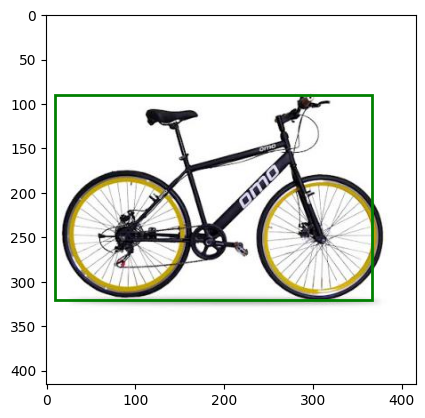

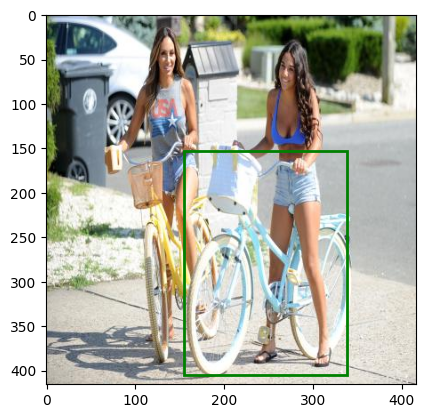

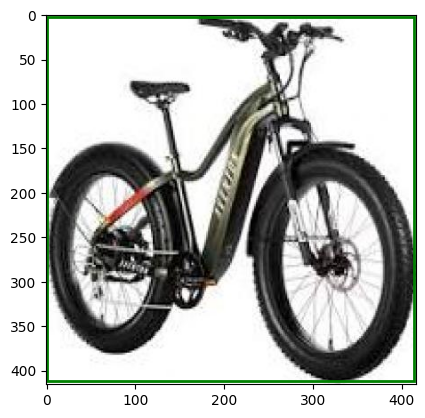

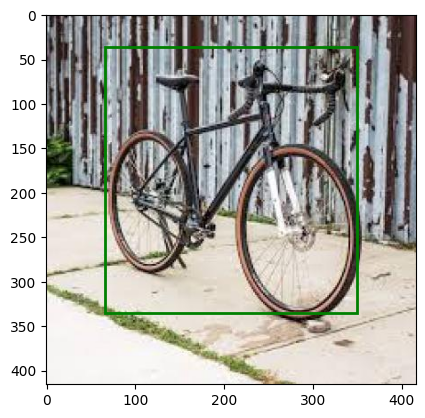

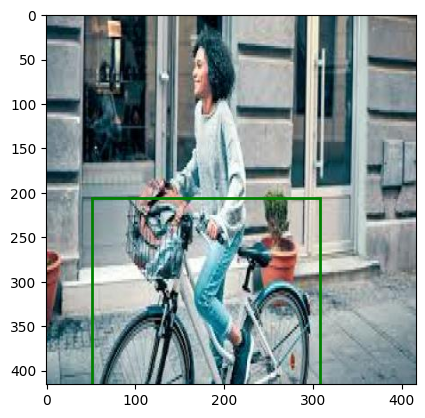

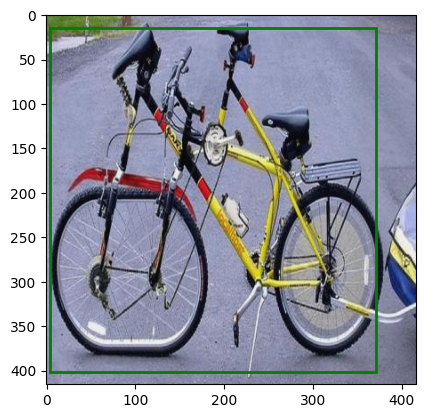

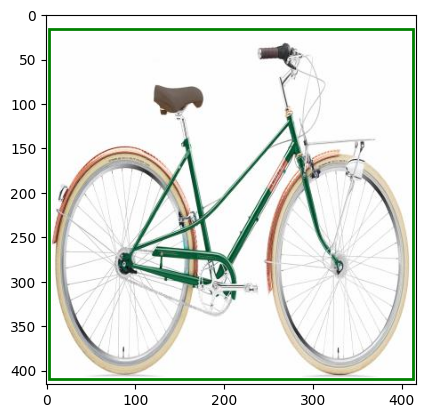

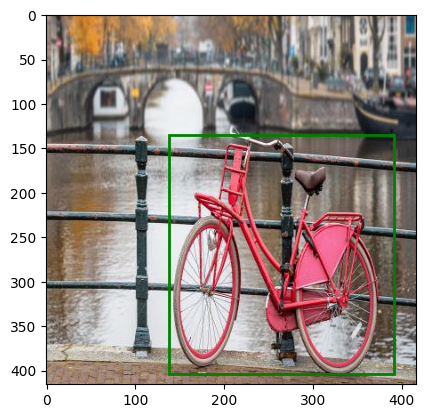

In [5]:
# coordonatele vor fi tinute minte
localizare_automata = {}

for result,image_path in zip(processed_images,images):
    found = False
    predicted_bike_bb = []
    for ob in result.objects:
        if (ob.object_property.lower() == "bicycle" or ob.object_property.lower() == "bike" or ob.object_property.lower() == "bicycles" or ob.object_property.lower() == "bikes"):
            predicted_bike_bb = [ob.rectangle.x, ob.rectangle.y, ob.rectangle.w, ob.rectangle.h]
            found = True

    if found:
        localizare_automata[image_path.name] = predicted_bike_bb

        im = plt.imread(image_path)
        fig = plt.imshow(im)
        fig.axes.add_patch(plt.Rectangle(xy = (predicted_bike_bb[0], predicted_bike_bb[1]), width = predicted_bike_bb[2], height = predicted_bike_bb[3], fill = False, color = "green", linewidth = 2))

        plt.show()


b) etichetarea (fara ajutorul algoritmilor de AI) acestor imagini cu chenare care sa incadreze cat mai exact bicicletele. Care task dureaza mai mult (cel de la punctul a sau cel de la punctul b)?

{'bike1.jpg': (4, 31, 409, 379), 'bike02.jpg': (14, 87, 369, 237), 'bike03.jpg': (62, 139, 288, 271), 'bike04.jpg': (3, 2, 413, 412), 'bike05.jpg': (65, 49, 294, 298), 'bike06.jpg': (63, 139, 285, 270), 'bike07.jpg': (56, 199, 246, 217), 'bike08.jpg': (50, 2, 341, 357), 'bike09.jpg': (4, 8, 378, 401), 'bike10.jpg': (139, 124, 238, 283)}


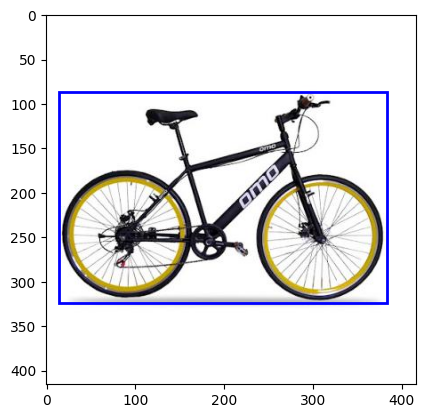

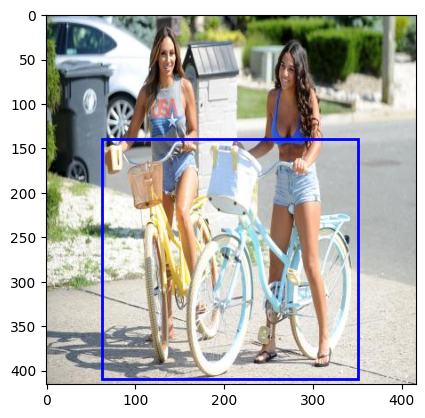

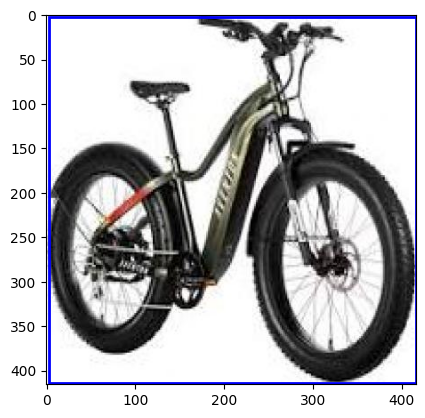

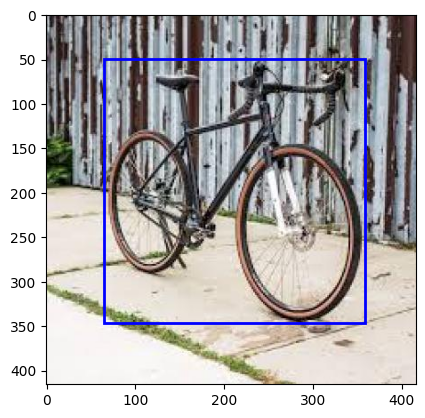

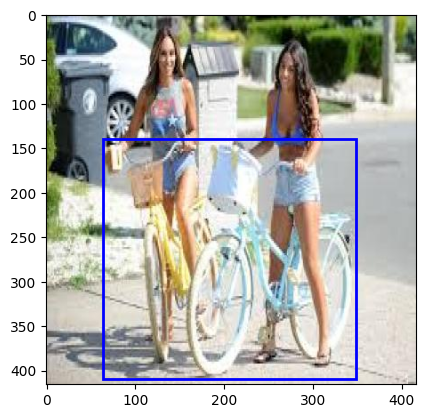

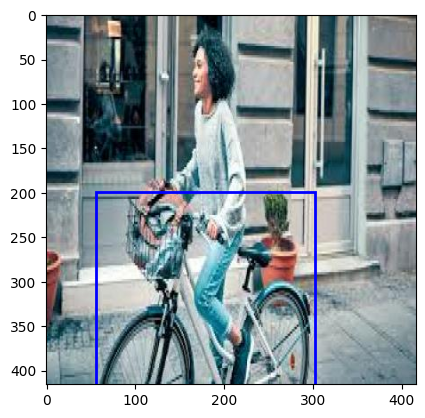

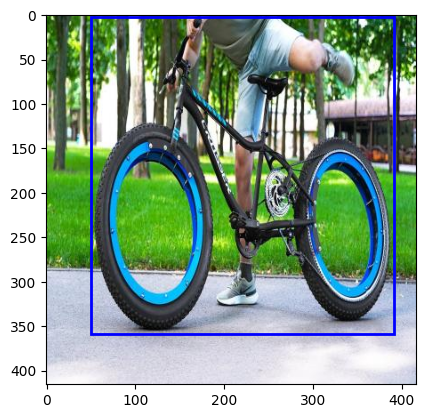

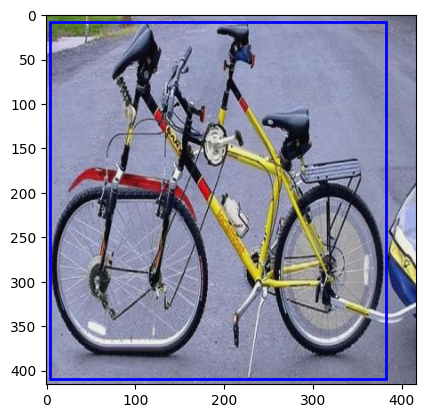

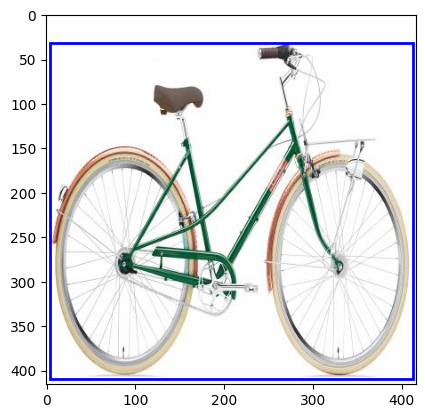

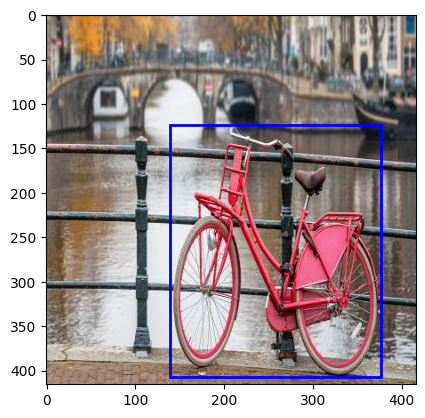

In [6]:
data_positions = pd.read_csv('bike_positions.csv')

# se extrag coordonatele + width + height din json-ul din fisierul csv
def extract_coords(row):
    shape = json.loads(row['region_shape_attributes'])
    return row['filename'], shape['x'], shape['y'], shape['width'], shape['height']

positions = {}

for _, row in data_positions.iterrows():
    rez = extract_coords(row)
    positions[rez[0]] = (rez[1],rez[2],rez[3],rez[4])

print(positions)

for index,image_path in enumerate(images):
    if expectedVector[index] == "bike":
        coords = positions[image_path.name]

        im = plt.imread(image_path)
        fig = plt.imshow(im)
        fig.axes.add_patch(plt.Rectangle(xy = (coords[0], coords[1]), width = coords[2], height = coords[3], fill = False, color = "blue", linewidth = 2))

        plt.show()


c) determinarea performantei algoritmului de la punctul a) avand in vedere etichetarile realizate la punctul b (se vor folosi cel putin 2 metrici)

In [7]:
# se vor lua in considerare numai imaginile in care s-au recunoscut a fi biciclete
# se vor lua in considerare numai imaginile in care s-au recunoscut a fi biciclete

# prima metrica: RMSE -> Root Mean Square Error

# mai intai se vor afisa erorile pe fiecare imagine, iar la final, media erorilor obtinute
print("VARIANTA RMSE:")
error_sum = 0
nr_of_bike_images = 0
for index,image_path in enumerate(images):
    if resultVector[index] == "bike":
        err = 0
        for v in zip(localizare_automata[image_path.name], positions[image_path.name]):
            err = err + (v[0] - v[1])**2
        err /= 4
        err = math.sqrt(err)
        error_sum += err
        nr_of_bike_images += 1
        print(f"{image_path.name} detection error: ", err)

print()
print("MEDIA ERORILOR: ", error_sum/nr_of_bike_images)


# a doua metrica -> IoU (Intersection over Union)
print("\n\nVARIANTA INTERSECTION OVER UNION:")
def IoU(lista_results,lista_real):
    width = lista_real[2]
    height = lista_real[3]

    #trebuie determinate colturile extreme (minime si maxime)
    #se determina coordonatele extreme

    #coltul din stanga sus al intersectiei
    xmin2 = max(lista_results[0],lista_real[0])
    ymin2 = max(lista_results[1],lista_real[1])


    #coltul din dr jos al intersectiei
    xmax2 = min(lista_results[0]+ lista_results[2],lista_real[0]+width)
    ymax2 = min(lista_results[1] +lista_results[3],lista_real[1]+height)

    lungime_intersectie = max(0,xmax2 - xmin2)
    inaltime_intersectie =max(0,ymax2 - ymin2)
    arie_intersectie = lungime_intersectie * inaltime_intersectie

    arie_reuniune = max(0,(lista_results[2])) * max(0,(lista_results[3])) + height * width - arie_intersectie

    return arie_intersectie/arie_reuniune

error_sum = 0
for index,image_path in enumerate(images):
    if resultVector[index] == "bike":
        similarity = IoU(localizare_automata[image_path.name],positions[image_path.name])
        err = 1 - similarity
        print(f"{image_path.name} detection error: ", err)
        error_sum += err

print()
print("MEDIA ERORILOR: ", error_sum/nr_of_bike_images)

VARIANTA RMSE:
bike02.jpg detection error:  7.314369419163897
bike03.jpg detection error:  71.11785992280701
bike04.jpg detection error:  1.8708286933869707
bike05.jpg detection error:  8.54400374531753
bike07.jpg detection error:  7.810249675906654
bike09.jpg detection error:  9.027735042633894
bike1.jpg detection error:  10.618380290797651
bike10.jpg detection error:  11.651180197731044

MEDIA ERORILOR:  15.994325873468078


VARIANTA INTERSECTION OVER UNION:
bike02.jpg detection error:  0.08234019501625134
bike03.jpg detection error:  0.4091328413284133
bike04.jpg detection error:  0.016780833907086956
bike05.jpg detection error:  0.11340657896178152
bike07.jpg detection error:  0.07239819004524883
bike09.jpg detection error:  0.06057607304490098
bike1.jpg detection error:  0.04267450859000155
bike10.jpg detection error:  0.10319517012424884

MEDIA ERORILOR:  0.11256304887724167
